In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

### Let's make a better OHLC chart
---
Get the base data

In [2]:
with sqlite3.connect('/home/tst/python/Stocks/stocks.db') as con:
    stock_raw_df = pd.read_sql_query(
        con=con,
        sql="""
            SELECT
                dly.date,
                dly.open,
                dly.high,
                dly.low,
                dly.close,
                dly.volume,
                dly.ema_5,
                dly.ema_10,
                dly.ema_20,
                dly.upper_channel,
                dly.lower_channel,
                dly.fast_line,
                dly.signal_line,
                dly.macd_histogram,
                dly.impulse,
                wly.upper_channel AS weekly_upper_channel,
                wly.lower_channel AS weekly_lower_channel,
                wly.ema_5 AS weekly_ema_5,
                wly.ema_10 AS weekly_ema_10,
                wly.ema_20 AS weekly_ema_20
            FROM
                daily dly
            INNER JOIN
                weekly wly
                    ON dly.symbol = wly.symbol
                    AND dly.date BETWEEN wly.date AND date(wly.date, '+5 day')
            WHERE
                dly.symbol = 'LEG'
                AND dly.date >= date('now', '-366 day')
            ORDER BY
                dly.date
        """
    )

    bom_df = pd.read_sql_query(
        con=con,
        sql="""
            SELECT
                year,
                month,
                min(date) AS 'BOM'
            FROM
                calendar
            WHERE
                day_of_week < 5
                AND NOT is_market_holiday
                AND date >= date('now', '-365 day')
            GROUP BY
                1,2
            ORDER BY
                3 DESC
            LIMIT 12
        """
    )

### MACD Histogram
---
Needs distinction between positive and rising v. postive and falling vice versa

In [3]:
negative_but_rising = '#9B4D4C'
negative_but_falling = '#720000'
postive_but_rising = '#0D0D0D'
positive_but_falling = '#999999'

In [4]:
hist_df = stock_raw_df.copy()
hist_df['yest_hist'] = hist_df['macd_histogram'].shift(1)
hist_df = hist_df.dropna(subset=['yest_hist'])

hist_df.loc[(hist_df['macd_histogram'] < 0) & (hist_df['macd_histogram'] > hist_df['yest_hist']), 'color'] = negative_but_rising
hist_df.loc[(hist_df['macd_histogram'] < 0) & (hist_df['macd_histogram'] <= hist_df['yest_hist']), 'color'] = negative_but_falling
hist_df.loc[(hist_df['macd_histogram'] > 0) & (hist_df['macd_histogram'] >= hist_df['yest_hist']), 'color'] = postive_but_rising
hist_df.loc[(hist_df['macd_histogram'] > 0) & (hist_df['macd_histogram'] < hist_df['yest_hist']), 'color'] = positive_but_falling

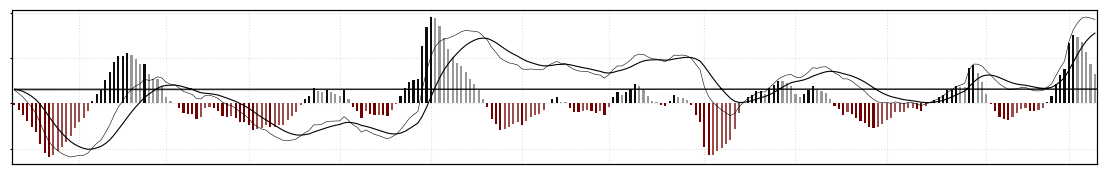

In [16]:
fig, ax = plt.subplots(figsize=(14,2))

ax.bar(x=hist_df['date'], height=hist_df['macd_histogram'], width=.5, color=hist_df['color'], zorder=3)
ax.grid(visible=True, linestyle=':', alpha=.4, zorder=0)
ax.set_xticks(bom_df['BOM'])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='x', direction='in', length=0)
ax.tick_params(axis='y', direction='out', length=1.5)
ax.set_xbound(lower=-.5, upper=len(hist_df) - .5)

line_axes = ax.twinx()

line_axes.plot(
    stock_raw_df['date'], 
    stock_raw_df['fast_line'], 
    linestyle='-', 
    color='k', 
    linewidth=.4
)

line_axes.plot(
    stock_raw_df['date'], 
    stock_raw_df['signal_line'], 
    linestyle='-', 
    color='k',
    linewidth=.8
)

line_axes.set_yticks([])
line_axes.set_xbound(lower=-.5, upper=len(hist_df) - .5)

### OHLC Chart
---
Needs the following:
1. ohlc plot with impulse color applied
2. 5, 10, 20 period EMA
3. Modified Keltner Channels

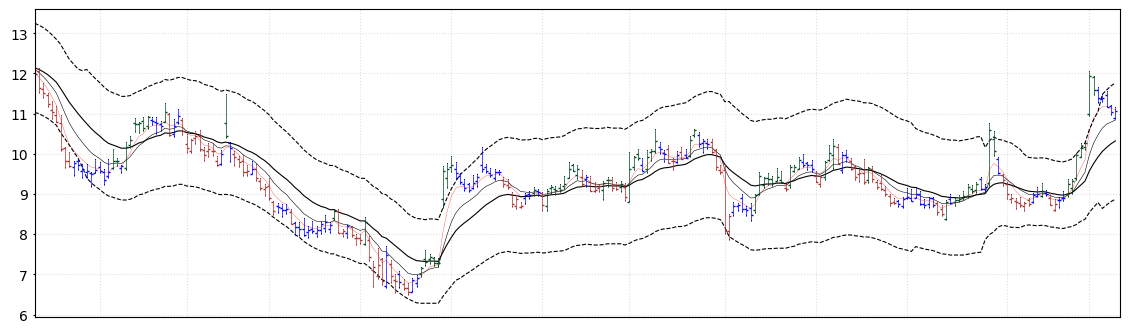

In [6]:
ohlc_df = hist_df.copy().drop(columns=['macd_histogram', 'yest_hist', 'color']).reset_index(drop=True)
ohlc_df['impulse'] = ohlc_df['impulse'].map({'Green': '#004820', 'Blue': '#0000FF', 'Red': '#AC2E2E'})

fig, ax = plt.subplots(figsize=(14,4))

ax.plot(ohlc_df['date'], ohlc_df['ema_5'], linestyle='-', color='red', linewidth=.2)
ax.plot(ohlc_df['date'], ohlc_df['ema_10'], linestyle='-', color='black', linewidth=.4)
ax.plot(ohlc_df['date'], ohlc_df['ema_20'], linestyle='-', color='black', linewidth=.8)
ax.plot(ohlc_df['date'], ohlc_df['upper_channel'], linestyle='--', color='black', linewidth=.8)
ax.plot(ohlc_df['date'], ohlc_df['lower_channel'], linestyle='--', color='black', linewidth=.8)

for i in range(len(ohlc_df)):
    date = ohlc_df['date'][i]
    high = ohlc_df['high'][i]
    low = ohlc_df['low'][i]
    open = ohlc_df['open'][i]
    close = ohlc_df['close'][i]
    color = ohlc_df['impulse'][i]
    
    ax.plot([date, date], [low, high], marker=',', linestyle='-', color=color, linewidth=.5)
    ax.plot(date, open, marker=0, color=color, markersize=1.5)
    ax.plot(date, close, marker=1, color=color, markersize=1.5)

ax.set_xbound(lower=0, upper=len(ohlc_df))
ax.grid(visible=True, linestyle=':', alpha=.4, zorder=0)
ax.set_xticks(bom_df['BOM'])
ax.set_xticklabels([])
ax.tick_params(axis='x', direction='in', length=0)
ax.tick_params(axis='y', direction='out', length=1.5)
plt.show()

### Volume Bar Chart
---

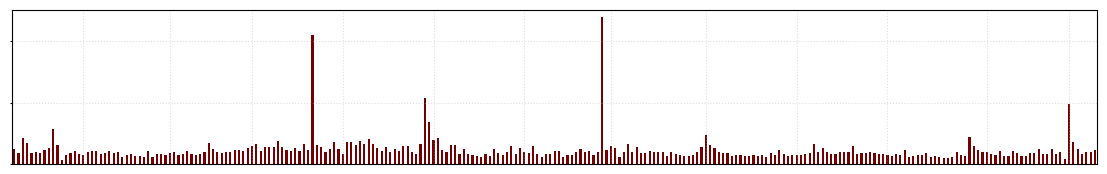

In [7]:
fig, ax = plt.subplots(figsize=(14, 2))

ax.bar(
    x=stock_raw_df['date'],
    height=stock_raw_df['volume'],
    color='#720000',
    width=.5
)

ax.set_xbound(lower=-.5, upper=len(stock_raw_df) - .5)
ax.grid(visible=True, linestyle=':', alpha=.4, zorder=0)
ax.set_xticks(bom_df['BOM'])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis='x', direction='in', length=0)
ax.tick_params(axis='y', direction='out', length=1.5)
plt.show()